In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.my_colors import palette_dark, palette_light, pink
from utility.adjust_redshift import adjust_redshift

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.get_absorption_intervals import get_absorption_intervals
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CIV_CONTINUUM_WINDOWS, CIV_FIT_WINDOW, NV_LYA_CONTINUUM_WINDOWS, LYA_NV_FIT_WINDOW, CIV_AIR, LYA_AIR, NV_AIR, C_KMS
from processing.scale_civ_to_nv import scale_civ_to_nv

from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel, Box1DKernel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':4.0,
        'xtick.minor.size':2.0,
        'ytick.major.size':4.0,
        'ytick.minor.size':2.0,
        'legend.frameon':False,
        'mathtext.fontset':'stix',
        'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)


found_desi_spectra_stats_path = "data/found_desi_spectra_stats.json"
relevant_erq_data_path = "data/relevant_erq_data.json"

In [2]:
desi = pd.read_json(found_desi_spectra_stats_path)
desi = desi.reset_index(drop=True)

sdss = pd.read_json(relevant_erq_data_path)

In [3]:
def test(data,i,j):    
    lam = np.array(data["wavelength"].squeeze())
    flux = np.array(data["flux"].squeeze())
    ivar = np.array(data["ivar"].squeeze())
    z = data["redshift"].squeeze()


    ## ADJUST REDSHIFT
    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)


    ## EXTRACT VALID PIXELS & REMOVE OUTLIERS

    # mask bad pixels, i.e. pixels where flux is zero, ivar is zero or infinity
    valid_pixel_mask = ((lam > 1150) & (lam < 1810)) & (ivar > 0) & np.isfinite(ivar) & (flux != 0)

    # apply mask
    lam = lam[valid_pixel_mask]
    flux = flux[valid_pixel_mask]
    ivar = ivar[valid_pixel_mask]

    # create noise
    noise = np.abs(1/np.sqrt(ivar))

    # remove spikes
    flux_clean, _ = remove_spikes(lam,flux,ivar=ivar)


    ## FIT CONTINUUM BELOW CIV
    result_civ_cont, continuum_civ, _ = fit_continuum(lam, flux_clean, ivar=ivar, windows=CIV_CONTINUUM_WINDOWS, lambda_ref=1700.0)


    ## QUALITY CUTS (based on CIV region)

    # TODO: fix all this, like i think it doesnt do shit currently and you need to get the values fixed
    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum_civ, result_civ_cont, max_slope=10.0)

    if rejected:
        print(f'Rejected because: {reason}')
        
    else:
        ## FIT CIV LINE

        # subtract CIV continuum
        flux_sub_civ = flux_clean - continuum_civ if not rejected else None

        # get absorption mask
        _, civ_absorption_mask = get_absorption_intervals(lam,flux_sub_civ,noise,continuum_civ, window=CIV_FIT_WINDOW)
        # civ_absorption_mask = (flux_sub_civ < -noise)

        # fit single gaussian, use result as parameter guesses for two gaussian fit
        result1_civ, profile1_civ = fit_single_gaussian(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, window=CIV_FIT_WINDOW)
        result2_civ, profile2_civ = fit_two_gaussians(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, single_result=result1_civ, window=CIV_FIT_WINDOW)

        # F-test which fit is better
        accept_two_civ, p_val_civ = ftest_which_gaussian(result1_civ, result2_civ)

        # depending on F-test result, assign respective profile and best parameter dictionary to general variables
        profile_civ = profile2_civ if accept_two_civ else profile1_civ
        params_dict_civ = result2_civ.params.valuesdict() if accept_two_civ else result1_civ.params.valuesdict()


        ## CONTINUUM BELOW NV AND LYA
        _, continuum_nv_lya, _ = fit_continuum(lam, flux_clean, ivar=ivar, windows=NV_LYA_CONTINUUM_WINDOWS+CIV_CONTINUUM_WINDOWS, lambda_ref=1290.0)  # fit continuum
        flux_sub_nv_lya = flux_clean - continuum_nv_lya  # subtract continuum


        ## NV PROFILE

        # make LYA mask
        # idea: mask left and right by a certain fixed window (left: 60% of lam(NV)-lam(LYA), right 40%),
        # then shift by the difference between CIV fit peak and air wavelengths to make it more robust in case of bad redshift values
        diff_civ = lam[np.argmax(profile_civ)] - CIV_AIR
        m = (NV_AIR-LYA_AIR)
        c = LYA_AIR + diff_civ
        lims = (c-0.6*m,c+0.5*m)
        lya_mask = (lam > lims[0]) & (lam < lims[1])
        
        # fit NV by scaling CIV template
        _, profile_nv = scale_civ_to_nv(lam,flux_sub_nv_lya,params_dict_civ,accept_two_civ,ivar=ivar,mask=lya_mask)
        

        ## LYA PROFILE

        # subtract NV profile
        flux_sub_lya = flux_sub_nv_lya - profile_nv

        # get absorption mask
        _, lya_absorption_mask = get_absorption_intervals(lam,flux_sub_lya,continuum_nv_lya,noise,window=LYA_NV_FIT_WINDOW)  # first is intervals for plotting

        # fit single gaussian, use result as parameter guesses for two gaussian fit
        result1_lya, profile1_lya = fit_single_gaussian(lam, flux_sub_lya, ivar=ivar, mask=lya_absorption_mask, window=LYA_NV_FIT_WINDOW)
        result2_lya, profile2_lya = fit_two_gaussians(lam, flux_sub_lya, ivar=ivar, mask=lya_absorption_mask, single_result=result1_lya, window=LYA_NV_FIT_WINDOW)

        # F-test which fit is better, assign to general variable
        accept_two_lya, p_val_lya = ftest_which_gaussian(result1_lya, result2_lya)
        profile_lya = profile2_lya if accept_two_lya else profile1_lya


        ## LINE MEASUREMENT

        # CIV
        line_stats_civ, civ_integration_win = measure_line(lam, profile_civ, flux_sub_civ, continuum_civ, window=CIV_FIT_WINDOW,get_window=True) 

        # NV
        flux_sub_nv = flux_sub_nv_lya - profile_lya  # subtract Lya profile
        line_stats_nv, nv_integration_win = measure_line(lam,profile_nv,flux_sub_nv,continuum_nv_lya,window=LYA_NV_FIT_WINDOW,get_window=True)

        # Lya
        line_stats_lya, lya_integration_win = measure_line(lam,profile_lya,flux_sub_lya,continuum_nv_lya,window=LYA_NV_FIT_WINDOW,get_window=True)
        

    #     ## RESULTS

    #     # extract
    #     sdss_name = data["sdss_name"][idx]

        rew_civ = line_stats_civ["ew_aa"]
        rew_nv = line_stats_nv["ew_aa"]
        rew_lya = line_stats_lya["ew_aa"]

        plot_mask = (lam > 1130) & (lam < 1610)
        lya_nv_plot_mask = ((profile_lya > 10E-4) | (profile_nv > 10E-4))
        
        ax[i,j].plot(lam[plot_mask], convolve(flux[plot_mask],Box1DKernel(3)),linewidth=0.6,color="black")
        ax[i,j].plot(lam[plot_mask & lya_nv_plot_mask ],profile_lya[plot_mask & lya_nv_plot_mask ]+continuum_nv_lya[plot_mask & lya_nv_plot_mask ],linewidth=1.5,label=r"Ly$\alpha$: "+f"{rew_lya:.2f}",color=palette_dark[0])
        ax[i,j].plot(lam[plot_mask & lya_nv_plot_mask ],profile_nv[plot_mask & lya_nv_plot_mask ]+continuum_nv_lya[plot_mask & lya_nv_plot_mask ],linewidth=1.5,label=f"NV: {rew_nv:.2f}",color=palette_dark[2])
        ax[i,j].plot(lam[plot_mask & (profile_civ > 10E-4)],profile_civ[plot_mask & (profile_civ > 10E-4)]+continuum_civ[plot_mask & (profile_civ > 10E-4)],linewidth=1.5,label=f"CIV: {rew_civ:.2f}",color=palette_dark[3])
        
        ax[i,j].legend(loc="upper right",handlelength=0, handletextpad=0,bbox_to_anchor=(1.004,1.03))
    
    # ax[i,j].text(0.05, 0.95, stat_label ,transform=ax[i,j].transAxes,ha='left', va='top')
        

In [4]:
idxs_to_plot = ["131722.85+322207.5","122000.68+064045.3","134001.90+322155.9","082653.42+054247.3"]

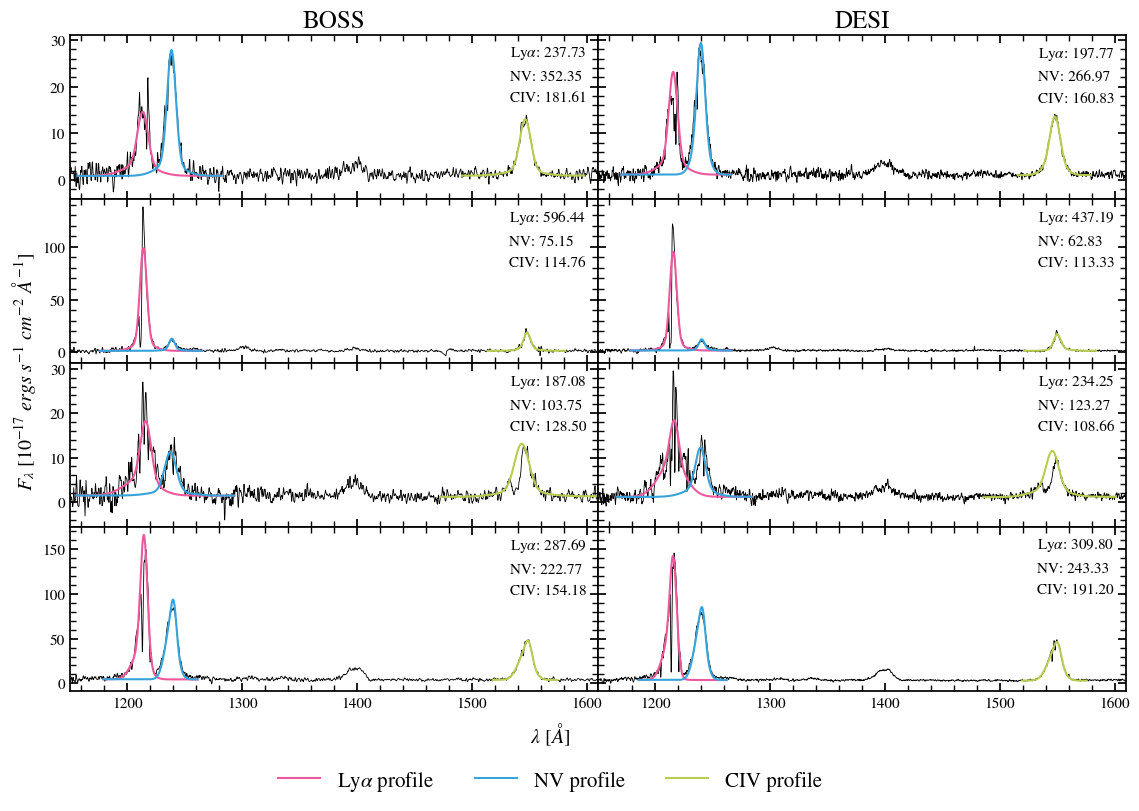

In [ ]:
sns.set_context("notebook")

fig,ax = plt.subplots(4,2,figsize=(12,8),sharex=True,sharey="row")
# plt.subplots_adjust(wspace=0, hspace=0)

for i in range(4):
    test(sdss[sdss["sdss_name"]==idxs_to_plot[i]],i,0)
    test(desi[desi["sdss_name"]==idxs_to_plot[i]],i,1)
    

ax[0,0].set_xlim(1150,1610)

fig.supxlabel(r"$\lambda$ [$\AA$]",y=0.03)x
fig.supylabel(r"$F_{\lambda}~[10^{-17}~ergs~s^{-1}~cm^{-2}~{\AA}^{-1}]$",x=0.05)

ax[0,0].set_title("BOSS",fontsize=18)
ax[0,1].set_title("DESI",fontsize=18)

handles, labels = ax[0,0].get_legend_handles_labels()

leg = fig.legend(
    handles, [r"Ly$\alpha$ profile","NV profile","CIV profile"],
    loc='lower center',x
    bbox_to_anchor=(0.5, -0.05), 
    ncol=len(labels),              
    frameon=False,
    fontsize=15,
    markerscale=4
)

for legobj in leg.legend_handles:
    if isinstance(legobj, plt.Line2D):
        legobj.set_markeredgewidth(2)
    else:
        legobj.set_linewidth(4)

fig.subplots_adjust(
    left=0.1, right=0.98, bottom=0.1, top=0.92,
    wspace=0, hspace=0                             
)


plt.plot()

plt.savefig("images/example_spectra.svg",bbox_inches='tight')

